### Ridge Regression Class


In [5]:
import numpy as np

class ridge_regression:
    def __init__(self, alpha: float = 1.0, beta: float = 1.0):
        '''
        Initializes the Ridge Regression model with prior precision (alpha) and noise precision (beta).

        Args:
            alpha (float): Precision of the weights prior. Default is 1.0.
            beta (float): Precision of the noise. Default is 1.0.
        '''
        if not isinstance(alpha, (int, float)) or alpha <= 0:
            raise ValueError("Alpha must be a positive float.")
        if not isinstance(beta, (int, float)) or beta <= 0:
            raise ValueError("Beta must be a positive float.")

        self.alpha = alpha
        self.beta = beta
        self.w_mean = None
        self.w_covariance = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        '''
        Fits the Bayesian Ridge Regression model to the training data.
        Estimates the posterior mean and covariance of the weights.

        Args:
            X (np.ndarray): Training input features, expected to be a 2D array.
            y (np.ndarray): Training target values, expected to be a 1D array.
        '''
        X = np.asarray(X)
        y = np.asarray(y)

        if X.ndim != 2:
            raise ValueError(f"X must be a 2D array, but got {X.ndim}D array.")
        if y.ndim != 1:
            if y.ndim == 2 and y.shape[1] == 1:
                y = y.ravel()
            else:
                raise ValueError(f"y must be a 1D array, but got {y.ndim}D array.")
        if X.shape[0] != y.shape[0]:
            raise ValueError("Number of samples in X and y must be consistent.")

        # Add bias term (a column of ones) to X
        X_biased = np.hstack([np.ones((X.shape[0], 1)), X])

        # Calculate posterior covariance (S)
        # S_inv = alpha * I + beta * X_biased.T @ X_biased
        identity_matrix = np.eye(X_biased.shape[1])
        S_inv = self.alpha * identity_matrix + self.beta * X_biased.T @ X_biased
        self.w_covariance = np.linalg.inv(S_inv)

        # Calculate posterior mean (m)
        # m = beta * S @ X_biased.T @ y
        self.w_mean = self.beta * self.w_covariance @ X_biased.T @ y

        print("Model fitted successfully. Posterior mean and covariance of weights estimated.")

    def predict(self, X: np.ndarray):
        '''
        Predicts the mean and variance for new input data X.

        Args:
            X (np.ndarray): New input features, expected to be a 2D array.

        Returns:
            tuple: A tuple containing:
                - y_pred_mean (np.ndarray): Predictive mean for new data.
                - y_pred_variance (np.ndarray): Predictive variance for new data.
        '''
        if self.w_mean is None or self.w_covariance is None:
            raise RuntimeError("Model has not been fitted yet. Call fit() first.")

        X = np.asarray(X)
        if X.ndim != 2:
            raise ValueError(f"X must be a 2D array, but got {X.ndim}D array.")

        # Add bias term (a column of ones) to X to match the dimensionality used during fitting
        X_biased = np.hstack([np.ones((X.shape[0], 1)), X])

        if X_biased.shape[1] != self.w_mean.shape[0]:
            raise ValueError("Number of features in X does not match the fitted model. Ensure bias term is consistent.")

        # Calculate predictive mean
        y_pred_mean = X_biased @ self.w_mean

        # Calculate predictive variance
        # var = 1/beta + X_biased @ S @ X_biased.T (diagonal elements)
        y_pred_variance = 1 / self.beta + np.diag(X_biased @ self.w_covariance @ X_biased.T)

        print("Predictions made successfully.")
        return y_pred_mean, y_pred_variance


Generate synthetic 1D data with a linear relationship and Gaussian noise


In [6]:
import numpy as np

# Define the parameters for the true underlying linear function
true_slope = 2.5
true_intercept = -1.0
noise_std = 1.5 # Standard deviation of the Gaussian noise

# Generate a 1D array X of input values
X_start = -5
X_end = 5
num_samples = 100
X = np.linspace(X_start, X_end, num_samples)

# Calculate the true target values y_true
y_true = true_slope * X + true_intercept

# Generate a 1D array of Gaussian noise
noise = np.random.normal(loc=0, scale=noise_std, size=num_samples)

# Add the generated noise to y_true to create the final synthetic target values y
y = y_true + noise

# Reshape X into a 2D array
X_reshaped = X.reshape(-1, 1)

In [7]:
ridge_model = ridge_regression(alpha=1.0, beta=1/noise_std**2) # Initialize model with alpha and beta based on noise_std
ridge_model.fit(X_reshaped, y)
print("Bayesian Ridge Regression model fitted to synthetic data.")

Model fitted successfully. Posterior mean and covariance of weights estimated.
Bayesian Ridge Regression model fitted to synthetic data.


In [8]:
y_pred_mean, y_pred_variance = ridge_model.predict(X_reshaped)
print("Predictions for training data generated successfully.")

Predictions made successfully.
Predictions for training data generated successfully.


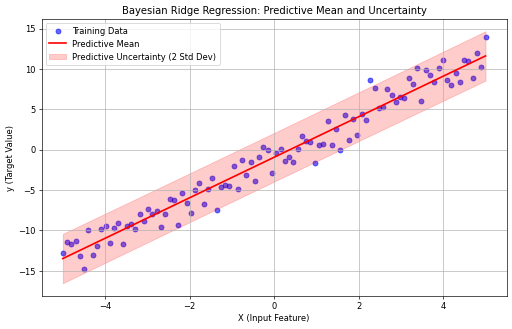

Visualization of predictive mean and uncertainty completed.


In [9]:
import matplotlib.pyplot as plt

# Calculate predictive standard deviation
y_pred_std = np.sqrt(y_pred_variance)

# Plotting
plt.figure(figsize=(10, 6), dpi=60)

# Plot training data
plt.scatter(X_reshaped, y, label='Training Data', color='blue', alpha=0.6)

# Plot predictive mean
plt.plot(X_reshaped, y_pred_mean, label='Predictive Mean', color='red', linewidth=2)

# Plot predictive uncertainty (2 standard deviations)
plt.fill_between(
    X_reshaped.flatten(), # Flatten X_reshaped for fill_between
    y_pred_mean - 2 * y_pred_std, # Lower bound
    y_pred_mean + 2 * y_pred_std, # Upper bound
    color='red', alpha=0.2, label='Predictive Uncertainty (2 Std Dev)'
)

plt.title('Bayesian Ridge Regression: Predictive Mean and Uncertainty')
plt.xlabel('X (Input Feature)')
plt.ylabel('y (Target Value)')
plt.legend()
plt.grid(True)
plt.show()

print("Visualization of predictive mean and uncertainty completed.")